# AutoEIT — Anomalous Recording Analysis
Identifies recordings whose item count falls outside the expected range (30–40) and plots
the language detected at each item index for each anomaly group.

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

## Config

In [2]:
TRANSCRIBED_ROOT = Path("../../data/transcribed/v1")
VERSIONS = ["version_a", "version_b"]

LOW_THRESHOLD = 30   # recordings with item_count < LOW_THRESHOLD are "short" anomalies
HIGH_THRESHOLD = 40  # recordings with item_count > HIGH_THRESHOLD are "long" anomalies

## Load summaries

In [3]:
recording_rows = []
item_rows = []

for version in VERSIONS:
    version_dir = TRANSCRIBED_ROOT / version
    if not version_dir.exists():
        continue
    for summary_path in sorted(version_dir.glob("*/summary.json")):
        with open(summary_path) as f:
            s = json.load(f)
        recording_rows.append({
            "recording": s["recording"],
            "version": s["version"],
            "item_count": s["item_count"],
        })
        for it in s["items"]:
            item_rows.append({
                "recording": s["recording"],
                "version": s["version"],
                **it,
            })

df_rec = pd.DataFrame(recording_rows)
df_items = pd.DataFrame(item_rows)
df_items["language_grouped"] = df_items["language"].apply(
    lambda l: l if l in ("en", "es") else "other"
)

print(f"{len(df_rec)} recordings, {len(df_items)} items total")

205 recordings, 8481 items total


## Identify anomaly groups

In [4]:
short_recs = df_rec[df_rec["item_count"] < LOW_THRESHOLD][["recording", "version", "item_count"]]
long_recs  = df_rec[df_rec["item_count"] > HIGH_THRESHOLD][["recording", "version", "item_count"]]
good_recs = df_rec[(df_rec["item_count"] <= HIGH_THRESHOLD) & (df_rec["item_count"] >= LOW_THRESHOLD)][["recording", "version", "item_count"]]


print(f"Short anomalies (< {LOW_THRESHOLD} items): {len(short_recs)} recordings")
display(short_recs.sort_values("item_count").reset_index(drop=True))

print(f"\nLong anomalies (> {HIGH_THRESHOLD} items): {len(long_recs)} recordings")
display(long_recs.sort_values("item_count", ascending=False).reset_index(drop=True))

print(f"\nGood recordings ({LOW_THRESHOLD} items <= x <= {HIGH_THRESHOLD} items): {len(good_recs)} recordings")
display(good_recs.sort_values("item_count", ascending=False).reset_index(drop=True))

Short anomalies (< 30 items): 9 recordings


,recording,version,item_count
0,038066_EITv-1A,version_a,1
1,038039_EITv-2B,version_b,1
2,038test_EITvA1,version_a,2
3,038test_EITvB2,version_b,7
4,038065_EITv-1B,version_b,10
5,038063_EITv-2A,version_a,13
6,038049_EIT-2A,version_a,21
7,038049_EIT-1B,version_b,23
8,038009_EIT-1A,version_a,29



Long anomalies (> 40 items): 49 recordings


,recording,version,item_count
0,038019_EIT-2B,version_b,75
1,038.099_EIT1_vB,version_b,73
2,038008_EIT-2A,version_a,72
3,038012_EIT-2A,version_a,72
4,038016_EIT-2A,version_a,72
5,038.084_EIT2_vB,version_b,71
6,038028_EITv-1B,version_b,70
7,038.107_EIT1_vB,version_b,69
8,038.090_EIT2_vB,version_b,68
9,038.097_EIT1_vB,version_b,67



Good recordings (30 items <= x <= 40 items): 147 recordings


,recording,version,item_count
0,038.092_EITv-1A,version_a,40
1,038027_EIT-1A,version_a,40
2,038020_EIT-2A,version_a,40
3,038.094_EITv-2B,version_b,40
4,038041_EITv-1A,version_a,40
...,...,...,...
142,038010_EIT-1B,version_b,35
143,038067_EITv1B,version_b,35
144,038023_EIT-2B,version_b,35
145,038009_EIT-2B,version_b,34


## Helper — language-by-index plot

In [5]:
lang_colors = {"en": "#4C72B0", "es": "#DD8452", "other": "#888888"}

def plot_language_by_index(items_df: pd.DataFrame, title: str, save_path: str | None = None):
    pivot = (
        items_df.groupby(["index", "language_grouped"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["en", "es", "other"], fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(max(10, len(pivot) * 0.4 + 2), 4))
    pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85,
               color=[lang_colors[c] for c in pivot.columns])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Item index")
    ax.set_ylabel("Number of recordings")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(max(1, len(pivot) // 20)))
    ax.legend(title="Language", bbox_to_anchor=(1.01, 1), loc="upper left")
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

## Short anomalies — language by item index
Recordings with fewer than 30 items.

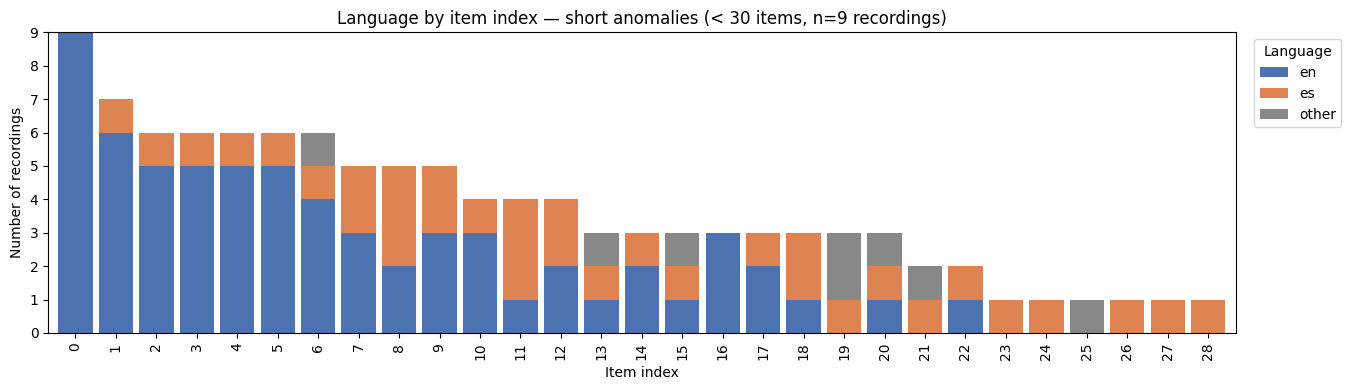

In [6]:
short_keys = set(zip(short_recs["recording"], short_recs["version"]))
short_items = df_items[
    df_items.apply(lambda r: (r["recording"], r["version"]) in short_keys, axis=1)
]

plot_language_by_index(
    short_items,
    title=f"Language by item index — short anomalies (< {LOW_THRESHOLD} items, n={len(short_recs)} recordings)",
    save_path="../plots/language_by_index_short_anomalies.png",
)

## Long anomalies — language by item index
Recordings with more than 40 items.

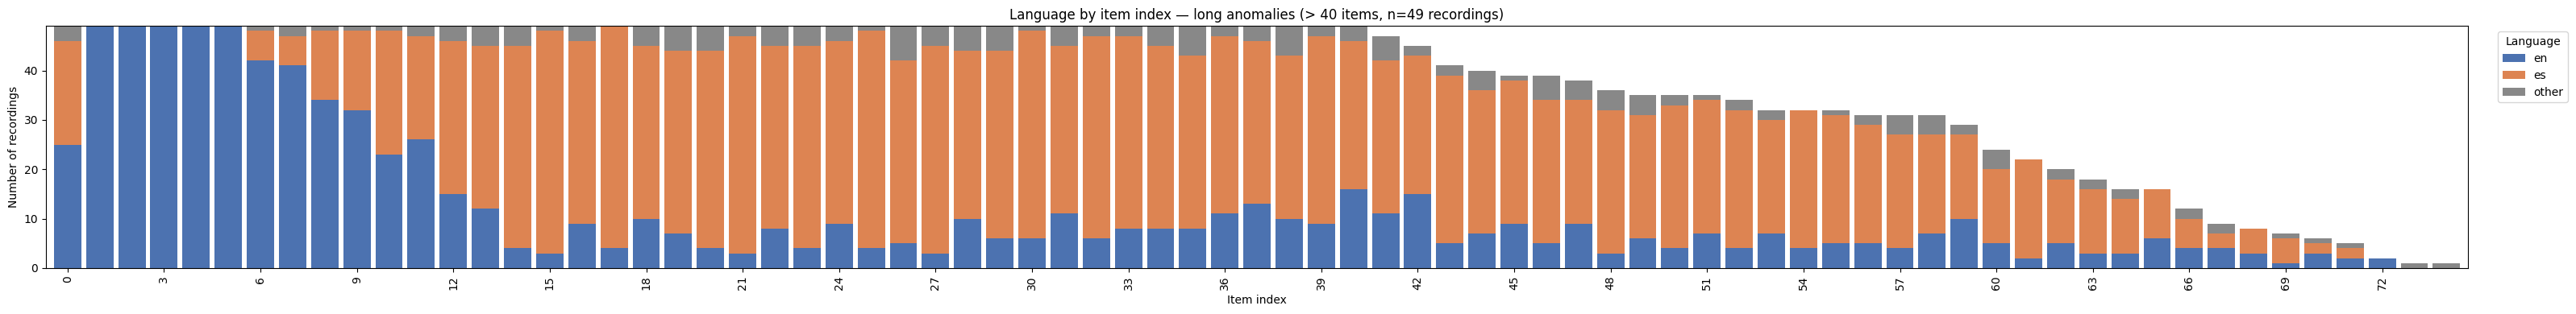

In [7]:
long_keys = set(zip(long_recs["recording"], long_recs["version"]))
long_items = df_items[
    df_items.apply(lambda r: (r["recording"], r["version"]) in long_keys, axis=1)
]

plot_language_by_index(
    long_items,
    title=f"Language by item index — long anomalies (> {HIGH_THRESHOLD} items, n={len(long_recs)} recordings)",
    save_path="../plots/language_by_index_long_anomalies.png",
)

## Good recrodings - language by item index
Recordings with more than 30 and less than 40 items.

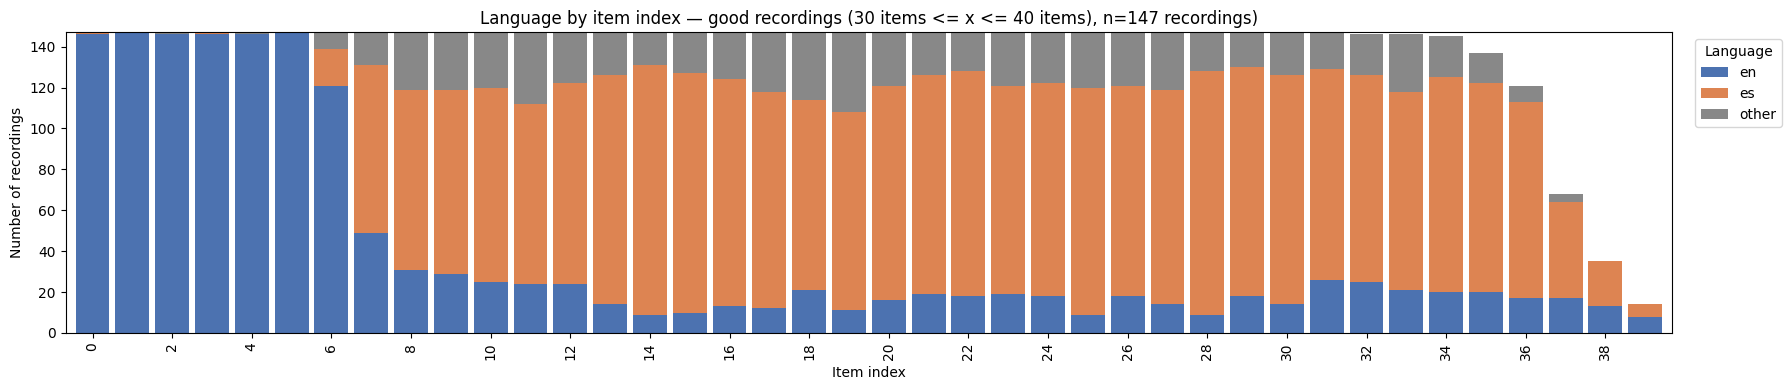

In [8]:
good_keys = set(zip(good_recs["recording"], good_recs["version"]))
good_items = df_items[
    df_items.apply(lambda r: (r["recording"], r["version"]) in good_keys, axis=1)
]

plot_language_by_index(
    good_items,
    title=f"Language by item index — good recordings ({LOW_THRESHOLD} items <= x <= {HIGH_THRESHOLD} items), n={len(good_recs)} recordings)",
    save_path="../plots/language_by_index_good_recordings.png",
)